## Objetivo

Se evalúa cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas.

### Carga de datos y vista rápida

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# carga de archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
traffic.head()

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238,2025
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016,2025


In [ ]:
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


### Se explora la estructura y tipo de datos

In [ ]:
traffic.info()
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo object requieren cambiar a tipo date
- Ninguna columna presenta datos ausentes (nulos)

In [6]:
# Examinar la estructura de eco
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, `PM2.5 (μg/m³)`y `Population (M)`son tipo object y deben convertirse a tipo integer o float
- No presenta datos ausentes (nulos)

### Se renombran columnas estandarizando nombres y se usa formato `snake_case`

In [ ]:
traffic = traffic.rename(columns={'Country':'country','City':'city','UpdateTimeUTC':'update_time_utc',
                                  'JamsDelay':'jams_delay','TrafficIndexLive':'traffic_index_live',
                                  'JamsLengthInKms':'jams_length_in_kms','JamsCount':'jams_count',
                                  'TrafficIndexWeekAgo':'traffic_index_week_ago',
                                  'UpdateTimeUTCWeekAgo':'update_time_utc_week_ago',
                                  'TravelTimeLivePer10KmsMins':'travel_time_live_per_10_kms_mins',
                                  'TravelTimeHistoricPer10KmsMins':'travel_time_historic_per_10_kms_mins',
                                  'MinsDelay':'mins_delay'})
# validación de cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10_kms_mins',
       'travel_time_historic_per_10_kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
eco = eco.rename(columns={'Year':'year','City':'city','Country':'country','City GDP/capita':'city_gdp/capita',
                          'Unemployment %':'unemployment_pct','PM2.5 (μg/m³)':'pm2.5_(μg/m³)',
                          'Population (M)':'population_m'})
# validación de cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp/capita', 'unemployment_pct',
       'pm2.5_(μg/m³)', 'population_m'],
      dtype='object')

### Corrección de formatos numéricos y de fecha

In [ ]:
#Se convierte formato de columnas de `traffic` a `datetime`

traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'],errors="coerce")
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'],errors="coerce")

# validación del cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                                Non-Null Count    Dtype         
---  ------                                --------------    -----         
 0   country                               1004464 non-null  object        
 1   city                                  1004464 non-null  object        
 2   update_time_utc                       1004464 non-null  datetime64[ns]
 3   jams_delay                            1004464 non-null  float64       
 4   traffic_index_live                    1004464 non-null  float64       
 5   jams_length_in_kms                    1004464 non-null  float64       
 6   jams_count                            1004464 non-null  float64       
 7   traffic_index_week_ago                1004464 non-null  float64       
 8   update_time_utc_week_ago              1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10_kms_mins      1004464 

In [ ]:
#Se estandarizan formatos numéricos eliminando símbolo de porcentaje, usando punto decimal
#Se crea columna `population` para obtener la población total

eco["city_gdp/capita"] = (eco["city_gdp/capita"].astype("string").str.replace(".","").str.replace(",",".").astype(float))

eco["unemployment_pct"] = (eco["unemployment_pct"].astype("string").str.replace("%","").str.replace(",",".").astype(float))

eco["population_m"] = (eco["population_m"].astype("string").str.replace(",",".").astype(float))

eco['population'] = eco["population_m"]*1000000

# validación del cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp/capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm2.5_(μg/m³)     30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp/capita,unemployment_pct,pm2.5_(μg/m³),population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


### Se crea columna `year` para filtrar por año 2024 y se crean dos nuevos DataFrames a partir de este filtro

In [ ]:
traffic["year"] = traffic["update_time_utc"].dt.year

# Validación del cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtrado de registros del año 2024
traffic_2024 = traffic[traffic["year"]==2024].copy()
eco_2024 = eco[eco["year"]==2024].copy()

# Revisión de dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp/capita,unemployment_pct,pm2.5_(μg/m³),population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


### Se calculan promedios de tráfico por ciudad de las métricas principales y se agrupan por `city`, `country` y `year`

In [ ]:
traffic_city_year_2024 = (
    traffic_2024
        .groupby(["city","country","year"])[[
        "jams_delay",
        "traffic_index_live",
        "jams_length_in_kms",
        "jams_count","mins_delay",
        "travel_time_live_per_10_kms_mins",
        "travel_time_historic_per_10_kms_mins"]]
    .mean()
    .reset_index())

# Se muestra resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### Se une la información de tráfico y economía en un DataFrame para analizar la correlación de condiciones económicas con movilidad urbana

In [ ]:
# Selección de columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10_kms_mins','travel_time_historic_per_10_kms_mins']

right_cols = ['city','year','city_gdp/capita','unemployment_pct','pm2.5_(μg/m³)','population']

traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unión de datasets
merged = pd.merge(traffic_2024_small,eco_2024_small,on=["city","year"],how="inner")

merged.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,city_gdp/capita,unemployment_pct,pm2.5_(μg/m³),population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0


### Visualización y análisis de relaciones entre economía y tráfico

Se analiza visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

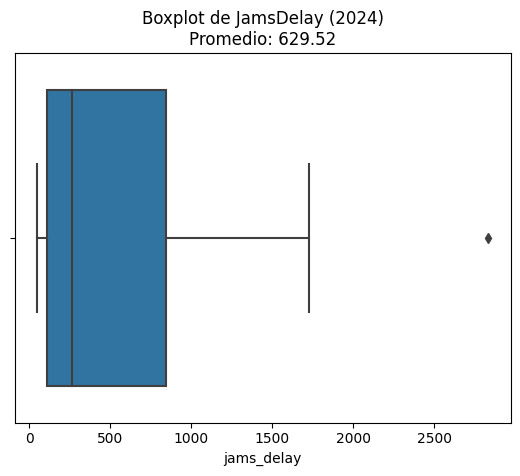

In [ ]:
# Creación de boxplot para observar el comportamiento de los minutos de congestion JamsDelay

sns.boxplot(data=merged,x="jams_delay")

mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


Text(0.5, 1.0, 'Distribución de la Economía\ncity_gdp_capita')

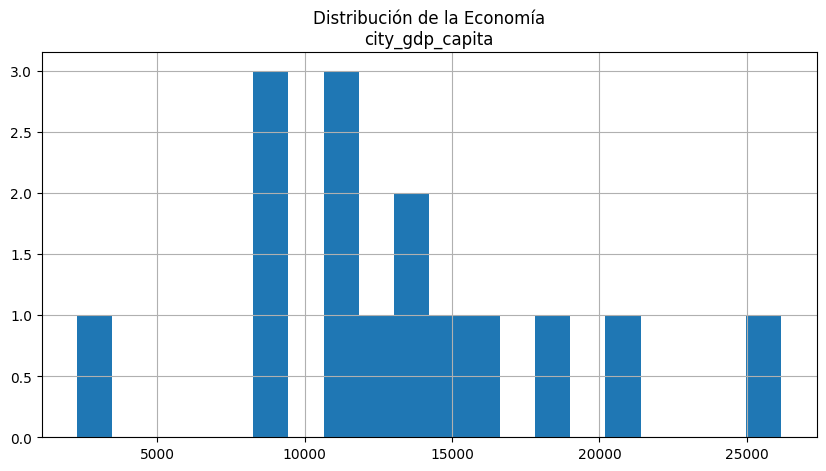

In [ ]:
# Creación de histograma para ver la distribución de la economía (city_gdp_capita)
merged["city_gdp/capita"].hist(bins=20,figsize=(10,5))
plt.title("Distribución de la Economía\ncity_gdp_capita")


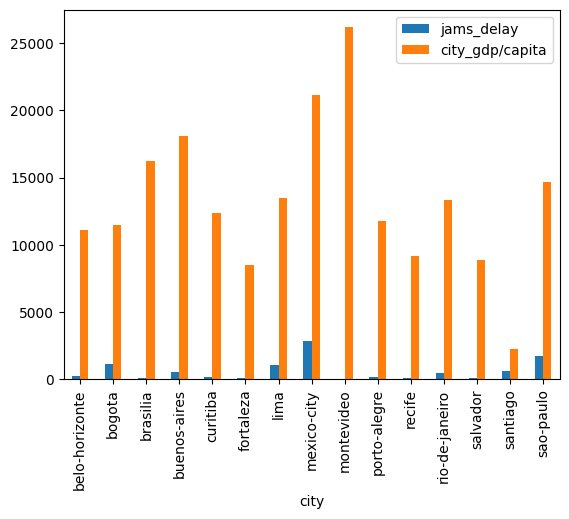

In [ ]:
# Creación de gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot(kind="bar",x="city", y=['jams_delay', 'city_gdp/capita'])
plt.xticks(rotation=90)
plt.show()

## Resumen ejecutivo

**Cobertura de datos:**  
- El análisis realizado se concentró en el periodo enero-diciembre del año 2024, tomando en cuenta lecturas de diferentes países alrededor del mundo, como Tokio, Ciudad de México, España, Turquía, Brasil, entre otros. En total se recabó información de 384 ciudades en 55 países.

**Metodología:**
- El proceso de análisis de la información se llevó a cabo validando toda la información con la que se contó proveniente de dos datasets. En ella, se preparó la información dando nombres consistentes a las columnas generales, evaluando el tipo de información que contenía cada una de ellas, dando el formato correcto para que los cálculos de medidas estadísticas no se vieran afectados por información nula o de formato inconsistente.
- Al contar con dos datasets se validó que hubiera información (columnas) que compartieran como lo fue "Año" y "Ciudad" considerándolas clave para que a partir de estas se pudieran combinar ambos datasets, permitiendo evaluar la información de una manera más completa siempre y cuando hubiera información registrada en las columnas clave en ambos dataset.
- Como recursos gráficos se utilizaron gráficos de barras, histogramas y boxplot para poder verificar la dispersión de la información con la que se cuenta así como métodos de comparación para buscar si existe o no una relación entre el PIB y el retraso provocado por congestión vehicular.

**Hallazgos:**  
- De manera general se puede decir que no necesariamente las ciudades que cuentan con un mayor tiempo en congestiones vehiculares se ven afectadas en su PIB.
- Se aprecia mediante el boxplot que la mayoría de las ciudades cuentan con niveles de tráfico moderado, sin embargo existen otras pocas ciudades pero con niveles muy altos.
- No se puede decir que existe una correlación entre el PIB y los problemas de movilidad urbana, ya que ciudades con mayor PIB presentan los índices más bajos y altos de tiempo en congestionamientos vehiculares. Esto tomando en consideración información clave por ciudad como el tiempo promedio de congestionamiento vehicular evaluada en el año 2024.

**Recomendaciones:**  
- Montevideo es una ciudad destacable que se recomienda analizar puntualmente, para verificar y buscar replicar su modelo económico y de movilidad urbana, ya que presenta los valores más bajos en tiempo de retraso por congestionamiento vehicular y las valores más altos en PIB. 